## 1.1 Importaciones y Configuración

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from collections import Counter
import copy, time, warnings
import random # Importante para la semilla completa

warnings.filterwarnings('ignore')

# Configuración global
CONFIG = {
    'data_path': 'C:/Users/pedro/Desktop/master/Machine Learning/ML-and-DL-final-project/Datos/images/MULTICLASE',
    'batch_size': 32,
    'img_size': 224,
    'seed': 42
}

# ============================================
# CONFIGURACIÓN DISPOSITIVO (GPU / CPU)
# ============================================

# 1. Definir el dispositivo automáticamente
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Configurar Semillas para Reproducibilidad (Funciona en ambos)
seed = CONFIG['seed']
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# 3. Configuraciones específicas si se usa GPU
if DEVICE.type == 'cuda':
    torch.cuda.set_device(0)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Determinismo en GPU
    torch.backends.cudnn.deterministic = True
    # Nota: benchmark=True puede reducir reproducibilidad a cambio de velocidad. 
    # Si quieres reproducibilidad exacta absoluta, ponlo en False.
    torch.backends.cudnn.benchmark = True 
    
    # Limpiar caché GPU
    torch.cuda.empty_cache()

# ============================================
# INFORMACIÓN DEL SISTEMA
# ============================================
print("="*60)
print(f"CONFIGURACIÓN COMPLETADA: Usando {DEVICE.type.upper()}")
print("="*60)
print(f"Device: {DEVICE}")
print(f"PyTorch Version: {torch.__version__}")

if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("GPU no detectada o no disponible. Se utilizará la CPU.")
    print("Nota: El entrenamiento en CPU será significativamente más lento.")

print("="*60)

CONFIGURACIÓN COMPLETADA: Usando CPU
Device: cpu
PyTorch Version: 2.2.2+cpu
GPU no detectada o no disponible. Se utilizará la CPU.
Nota: El entrenamiento en CPU será significativamente más lento.


In [7]:
# Cargar dataset
full_dataset = datasets.ImageFolder(root=CONFIG['data_path'])
class_names = full_dataset.classes
num_classes = len(class_names)
class_counts = Counter(full_dataset.targets)

print(f"{'='*50}")
print(f"DATASET: {len(full_dataset)} imágenes | {num_classes} clases")
print(f"{'='*50}\n")

for idx, name in enumerate(class_names):
    count = class_counts[idx]
    pct = 100 * count / len(full_dataset)
    bar = "█" * int(count / 5)
    marker = " ← MINORITARIA" if name == 'MEL' else ""
    print(f"{name}: {count:3d} ({pct:5.1f}%) {bar}{marker}")

print(f"\nRatio desbalance: {max(class_counts.values())/min(class_counts.values()):.1f}x")

DATASET: 802 imágenes | 6 clases

ACK: 150 ( 18.7%) ██████████████████████████████
BCC: 150 ( 18.7%) ██████████████████████████████
MEL:  52 (  6.5%) ██████████ ← MINORITARIA
NEV: 150 ( 18.7%) ██████████████████████████████
SCC: 150 ( 18.7%) ██████████████████████████████
SEK: 150 ( 18.7%) ██████████████████████████████

Ratio desbalance: 2.9x


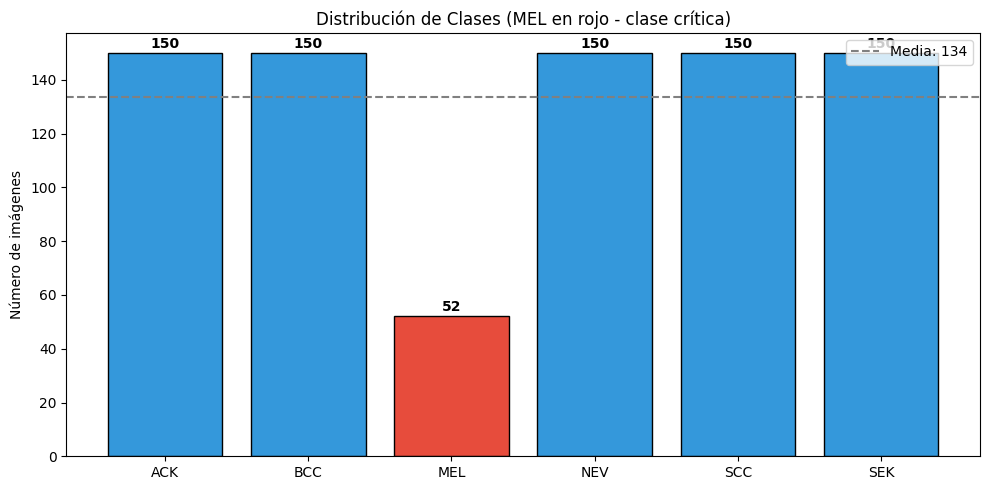

In [8]:
# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts[i] for i in range(num_classes)]
colors = ['#e74c3c' if n == 'MEL' else '#3498db' for n in class_names]
bars = ax.bar(class_names, counts, color=colors, edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.axhline(np.mean(counts), color='gray', linestyle='--', label=f'Media: {np.mean(counts):.0f}')
ax.set_title('Distribución de Clases (MEL en rojo - clase crítica)')
ax.set_ylabel('Número de imágenes'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
## 1.4 División Estratificada y Data Augmentation



Train: 64%

Validación: 16%

Test: 20%

In [16]:
# División estratificada 70/15/15
targets = full_dataset.targets
indices = list(range(len(full_dataset)))

temp_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=targets, random_state=CONFIG['seed'])
train_idx, val_idx = train_test_split(temp_idx, test_size=0.2, stratify=[targets[i] for i in temp_idx], random_state=CONFIG['seed'])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Train: 512 | Val: 129 | Test: 161


In [20]:
import pandas as pd
import os

# 1. Cargar el metadata
df_metadata = pd.read_csv('C:/Users/pedro/Desktop/master/Machine Learning/ML-and-DL-final-project/Datos/metadata.csv') 

# === CORRECCIÓN CLAVE ===
# Creamos una columna auxiliar 'id_limpio' en el metadata quitando la extensión (.png/.jpg)
# Esto convierte 'PAT_715_4072_827.png' en 'PAT_715_4072_827'
df_metadata['id_limpio'] = df_metadata['img_id'].astype(str).apply(lambda x: os.path.splitext(x)[0])

# 2. Obtener los IDs de las imágenes desde el dataset (sin extensión)
image_paths = [s[0] for s in full_dataset.samples]
# Esto obtiene 'PAT_715_4072_827' de la ruta del archivo
img_ids_from_folder = [os.path.splitext(os.path.basename(path))[0] for path in image_paths]

# 3. Asignar etiquetas (Train/Val/Test)
set_labels = [""] * len(full_dataset)
for i in train_idx: set_labels[i] = 'train'
for i in val_idx:   set_labels[i] = 'validation'
for i in test_idx:  set_labels[i] = 'test'

# 4. Crear DataFrame con las imágenes que tienes realmente en la carpeta
df_splits = pd.DataFrame({
    'img_id_carpeta': img_ids_from_folder, # Este es el ID sacado de tu carpeta
    'conjunto_train_test_val': set_labels
})

# 5. Hacer el Merge usando los IDs limpios
# Unimos la 'img_id_carpeta' con 'id_limpio' del metadata
df_merged = pd.merge(df_splits, df_metadata, left_on='img_id_carpeta', right_on='id_limpio', how='left')

# 6. Seleccionar y renombrar las columnas finales que pediste
# Queremos: img_id (original del metadata con .png), conjunto, diagnostic
df_final = df_merged[['img_id', 'conjunto_train_test_val', 'diagnostic']].copy()

# Verificaciones
print("="*50)
print("VERIFICACIÓN DE CRUCE")
print("="*50)
print(df_final.head())
print("\nConteo por conjunto:")
print(df_final['conjunto_train_test_val'].value_counts())

nulos = df_final['diagnostic'].isnull().sum()
if nulos > 0:
    print(f"\n❌ AÚN HAY {nulos} IMÁGENES SIN DIAGNÓSTICO.")
    print("Revisa si los nombres de archivo en la carpeta coinciden con los del CSV.")
else:
    print("\n✅ ÉXITO: Todas las imágenes se cruzaron correctamente con su diagnóstico.")

# 7. Guardar
#df_final.to_csv('dataset_split_final.csv', index=False)
display(df_final)

VERIFICACIÓN DE CRUCE
                 img_id conjunto_train_test_val diagnostic
0  PAT_104_1754_276.png                   train        ACK
1   PAT_108_424_944.png                    test        ACK
2    PAT_110_397_52.png                   train        ACK
3   PAT_126_190_376.png                   train        ACK
4   PAT_126_192_208.png              validation        ACK

Conteo por conjunto:
conjunto_train_test_val
train         512
test          161
validation    129
Name: count, dtype: int64

✅ ÉXITO: Todas las imágenes se cruzaron correctamente con su diagnóstico.


,img_id,conjunto_train_test_val,diagnostic
0,PAT_104_1754_276.png,train,ACK
1,PAT_108_424_944.png,test,ACK
2,PAT_110_397_52.png,train,ACK
3,PAT_126_190_376.png,train,ACK
4,PAT_126_192_208.png,validation,ACK
...,...,...,...
797,PAT_93_361_203.png,validation,SEK
798,PAT_93_361_231.png,validation,SEK
799,PAT_93_361_467.png,train,SEK
800,PAT_93_361_51.png,train,SEK


In [23]:
class_to_int = {
    'ACK': 0,
    'BCC': 1,
    'MEL': 2,
    'NEV': 3,
    'SCC': 4,
    'SEK': 5
}

# 2. Definir el diccionario de Número a Binario (Tu mapping solicitado)
# 0 (Benigno): ACK, NEV, SEK
# 1 (Maligno): BCC, MEL, SCC
int_to_binary = {
    0: 0, # ACK -> Benigno
    1: 1, # BCC -> Maligno
    2: 1, # MEL -> Maligno
    3: 0, # NEV -> Benigno
    4: 1, # SCC -> Maligno
    5: 0  # SEK -> Benigno
}

# 3. Aplicar los mapeos
# Primero creamos la columna numérica (0-5) basada en el texto del diagnóstico
df_final['multiclase'] = df_final['diagnostic'].map(class_to_int)

# Luego creamos la columna binaria (0-1) basada en la columna multiclase
df_final['biclase'] = df_final['multiclase'].map(int_to_binary)

# 4. Verificación
print("="*50)
print("VERIFICACIÓN DE ETIQUETAS")
print("="*50)
print(df_final[['diagnostic', 'multiclase', 'biclase']].head(10))

print("\nConteo Biclase (0=Benigno, 1=Maligno):")
print(df_final['biclase'].value_counts())

# 5. Guardar el archivo definitivo
df_final.to_csv('dataset_split_final_con_etiquetas.csv', index=False)
print("\nArchivo guardado con nuevas columnas.")

VERIFICACIÓN DE ETIQUETAS
  diagnostic  multiclase  biclase
0        ACK           0        0
1        ACK           0        0
2        ACK           0        0
3        ACK           0        0
4        ACK           0        0
5        ACK           0        0
6        ACK           0        0
7        ACK           0        0
8        ACK           0        0
9        ACK           0        0

Conteo Biclase (0=Benigno, 1=Maligno):
biclase
0    450
1    352
Name: count, dtype: int64

Archivo guardado con nuevas columnas.
